# Forklift Anomaly Detection Skeleton


## 0. パッケージのインストール


In [49]:
%pip install jupyterlab==4.4.1 matplotlib==3.10.1 numpy==2.2.4 pandas==2.2.3 scipy==1.15.2 scikit-learn==1.6.1 librosa==0.10.2.post1 soundfile==0.13.1


Note: you may need to restart the kernel to use updated packages.


In [50]:
from __future__ import annotations

from io import BytesIO
from pathlib import Path
from typing import Any

import shutil
import subprocess

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from scipy import signal
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler


In [51]:
DATA_DIR = Path("../data")
NORMAL_VIDEO_DIR = DATA_DIR / "normal"
ANOMARY_VIDEO_DIR = DATA_DIR / "anomary"
OUTPUT_DIR = Path("../outputs")
ANOMARY_LIKE_NORMAL_LIST_PATH = DATA_DIR / "anomary_like_normal.txt"

SPLIT_BASE_DIR = OUTPUT_DIR / "audio_dataset_split"
TRAIN_NORMAL_DIR = SPLIT_BASE_DIR / "train" / "normal"
EVAL_NORMAL_DIR = SPLIT_BASE_DIR / "eval" / "normal"
EVAL_ANOMARY_DIR = SPLIT_BASE_DIR / "eval" / "anomary"
AUDIO_CACHE_DIR = OUTPUT_DIR / "audio_cache"
EVALUATION_RESULTS_PATH = OUTPUT_DIR / "audio_evaluation_results.csv"
SPLIT_MANIFEST_PATH = SPLIT_BASE_DIR / "split_manifest.csv"

VIDEO_PROCESSING_ENABLED = False
TRAIN_SPLIT_RATIO = 0.8
SPLIT_RANDOM_SEED = 42

AUDIO_SAMPLE_RATE = 22050
AUDIO_MONO_CHANNELS = 1
AUDIO_HIGHPASS_CUTOFF_HZ = 20.0
AUDIO_N_FFT = 1024
AUDIO_WIN_LENGTH = 1024
AUDIO_HOP_LENGTH = 256
AUDIO_N_MELS = 64
AUDIO_FMIN_HZ = 20.0
AUDIO_FMAX_HZ = 10000.0
AUDIO_WINDOW_SEC = 0.5
AUDIO_WINDOW_HOP_SEC = 0.25
AUDIO_BAND_LIMITS_HZ = [(20, 200), (200, 1000), (1000, 4000), (4000, 10000)]
AUDIO_PCA_COMPONENTS = 32
AUDIO_ISOLATION_FOREST_RANDOM_STATE = 42
AUDIO_CLIP_SCORE_TOP_K = 3
NORMAL_SCORE_THRESHOLD_PERCENTILE = 95.0


## 1. 映像処理（無効化中）


In [52]:
# 音声だけの学習・推論に切り替えるため、映像処理は一旦実行しない。
print("Video preprocessing is disabled in this notebook revision.")


Video preprocessing is disabled in this notebook revision.


## 1.5 映像処理（無効化中）


In [53]:
# 音声実験中のため、レターボックス除去も実行しない。
print("Temporary letterbox removal is disabled.")


Temporary letterbox removal is disabled.


## 2. 映像処理（無効化中）


In [54]:
# 音声実験中のため、前後分割処理も実行しない。
print("Front / rear video split is disabled.")


Front / rear video split is disabled.


## 2.5 映像処理（無効化中）


In [55]:
# 音声実験中のため、映像の空フレーム除去も実行しない。
print("Uniform-frame trimming is disabled.")


Uniform-frame trimming is disabled.


## 3. データ分割と音声前処理


In [56]:
def ensure_output_directory(path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)


def reset_directory(path: Path) -> None:
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def show_figure(figure: plt.Figure) -> None:
    buffer = BytesIO()
    figure.savefig(buffer, format="png", bbox_inches="tight")
    plt.close(figure)
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))


def sanitize_stem(path: Path) -> str:
    return path.stem.replace(" ", "_").replace(":", "-")


def list_video_paths(directory: Path) -> list[Path]:
    if not directory.exists():
        return []
    return sorted(path for path in directory.glob("*.mp4") if path.is_file())


def load_force_eval_video_names(list_path: Path = ANOMARY_LIKE_NORMAL_LIST_PATH) -> list[str]:
    if not list_path.exists():
        return []

    video_names: list[str] = []
    for raw_line in list_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#"):
            continue
        video_names.append(line)
    return sorted(set(video_names))


def split_normal_videos(
    normal_video_paths: list[Path],
    force_eval_video_names: list[str] | None = None,
    train_ratio: float = TRAIN_SPLIT_RATIO,
    random_seed: int = SPLIT_RANDOM_SEED,
) -> tuple[list[Path], list[Path]]:
    if not normal_video_paths:
        return [], []

    force_eval_name_set = set(force_eval_video_names or [])
    forced_eval_paths = sorted([path for path in normal_video_paths if path.name in force_eval_name_set])
    remaining_paths = [path for path in normal_video_paths if path.name not in force_eval_name_set]

    if not remaining_paths:
        return [], forced_eval_paths

    rng = np.random.default_rng(random_seed)
    shuffled_indices = rng.permutation(len(remaining_paths))
    shuffled_paths = [remaining_paths[int(index)] for index in shuffled_indices]

    if len(shuffled_paths) == 1:
        return [], sorted(forced_eval_paths + shuffled_paths)

    desired_train_count = int(round(len(normal_video_paths) * float(train_ratio)))
    max_train_count = max(0, len(shuffled_paths) - 1)
    min_train_count = 1 if len(shuffled_paths) >= 2 else 0
    train_count = min(max(desired_train_count, min_train_count), max_train_count)

    train_paths = sorted(shuffled_paths[:train_count])
    eval_paths = sorted(forced_eval_paths + shuffled_paths[train_count:])
    return train_paths, eval_paths


def copy_dataset_split(
    train_normal_paths: list[Path],
    eval_normal_paths: list[Path],
    eval_anomary_paths: list[Path],
) -> dict[str, Any]:
    reset_directory(TRAIN_NORMAL_DIR)
    reset_directory(EVAL_NORMAL_DIR)
    reset_directory(EVAL_ANOMARY_DIR)

    manifest_rows: list[dict[str, Any]] = []

    for source_path in train_normal_paths:
        destination_path = TRAIN_NORMAL_DIR / source_path.name
        shutil.copy2(source_path, destination_path)
        manifest_rows.append(
            {
                "source_path": str(source_path),
                "copied_path": str(destination_path),
                "split_name": "train",
                "true_label": "normal",
                "video_name": source_path.name,
            }
        )

    for source_path in eval_normal_paths:
        destination_path = EVAL_NORMAL_DIR / source_path.name
        shutil.copy2(source_path, destination_path)
        manifest_rows.append(
            {
                "source_path": str(source_path),
                "copied_path": str(destination_path),
                "split_name": "eval",
                "true_label": "normal",
                "video_name": source_path.name,
            }
        )

    for source_path in eval_anomary_paths:
        destination_path = EVAL_ANOMARY_DIR / source_path.name
        shutil.copy2(source_path, destination_path)
        manifest_rows.append(
            {
                "source_path": str(source_path),
                "copied_path": str(destination_path),
                "split_name": "eval",
                "true_label": "anomary",
                "video_name": source_path.name,
            }
        )

    manifest_df = pd.DataFrame(manifest_rows)
    ensure_output_directory(SPLIT_MANIFEST_PATH)
    manifest_df.to_csv(SPLIT_MANIFEST_PATH, index=False)

    return {
        "train_normal_paths": sorted(TRAIN_NORMAL_DIR.glob("*.mp4")),
        "eval_normal_paths": sorted(EVAL_NORMAL_DIR.glob("*.mp4")),
        "eval_anomary_paths": sorted(EVAL_ANOMARY_DIR.glob("*.mp4")),
        "manifest_df": manifest_df,
    }


def build_audio_cache_path(video_path: Path, split_name: str, true_label: str) -> Path:
    return AUDIO_CACHE_DIR / split_name / true_label / f"{sanitize_stem(video_path)}.wav"


def extract_audio_to_wav(
    video_path: Path,
    output_wav_path: Path,
    sample_rate: int = AUDIO_SAMPLE_RATE,
    channels: int = AUDIO_MONO_CHANNELS,
) -> Path:
    ffmpeg_path = shutil.which("ffmpeg")
    if ffmpeg_path is None:
        raise FileNotFoundError("ffmpeg is required to extract audio but was not found in PATH.")

    ensure_output_directory(output_wav_path)
    command = [
        ffmpeg_path,
        "-hide_banner",
        "-loglevel",
        "error",
        "-y",
        "-i",
        str(video_path),
        "-vn",
        "-ac",
        str(channels),
        "-ar",
        str(sample_rate),
        "-c:a",
        "pcm_s16le",
        str(output_wav_path),
    ]
    subprocess.run(command, check=True)
    return output_wav_path


def load_audio_waveform(audio_path: Path, sample_rate: int = AUDIO_SAMPLE_RATE) -> tuple[np.ndarray, int]:
    waveform, actual_sample_rate = librosa.load(audio_path, sr=sample_rate, mono=True)
    return waveform.astype(np.float32), int(actual_sample_rate)


def preprocess_audio_waveform(
    waveform: np.ndarray,
    sample_rate: int,
    highpass_cutoff_hz: float = AUDIO_HIGHPASS_CUTOFF_HZ,
) -> np.ndarray:
    if waveform.size == 0:
        return waveform.astype(np.float32)

    centered = waveform.astype(np.float32) - float(np.mean(waveform))
    if highpass_cutoff_hz <= 0:
        return centered

    nyquist = 0.5 * float(sample_rate)
    normalized_cutoff = min(max(highpass_cutoff_hz / nyquist, 1e-6), 0.99)
    sos = signal.butter(2, normalized_cutoff, btype="highpass", output="sos")
    return signal.sosfiltfilt(sos, centered).astype(np.float32)


def compute_clipping_ratio(waveform: np.ndarray, clip_threshold: float = 0.999) -> float:
    if waveform.size == 0:
        return 0.0
    return float(np.mean(np.abs(waveform) >= clip_threshold))


def compute_spectral_flux(magnitude_spectrogram: np.ndarray) -> np.ndarray:
    if magnitude_spectrogram.shape[1] == 0:
        return np.zeros((0,), dtype=np.float32)
    frame_diff = np.diff(magnitude_spectrogram, axis=1, prepend=magnitude_spectrogram[:, :1])
    positive_diff = np.maximum(frame_diff, 0.0)
    return np.sqrt(np.sum(positive_diff**2, axis=0)).astype(np.float32)


def compute_crest_factor(
    waveform: np.ndarray,
    frame_length: int = AUDIO_WIN_LENGTH,
    hop_length: int = AUDIO_HOP_LENGTH,
) -> np.ndarray:
    if waveform.size == 0:
        return np.zeros((0,), dtype=np.float32)

    padded = np.pad(waveform, (frame_length // 2, frame_length // 2), mode="reflect")
    framed = librosa.util.frame(padded, frame_length=frame_length, hop_length=hop_length)
    peak = np.max(np.abs(framed), axis=0)
    rms = np.sqrt(np.mean(framed**2, axis=0))
    return (peak / np.maximum(rms, 1e-6)).astype(np.float32)


def compute_band_energy_features(
    power_spectrogram: np.ndarray,
    sample_rate: int,
    n_fft: int = AUDIO_N_FFT,
    band_limits_hz: list[tuple[int, int]] | None = None,
) -> dict[str, np.ndarray]:
    band_limits_hz = band_limits_hz or AUDIO_BAND_LIMITS_HZ
    fft_frequencies = librosa.fft_frequencies(sr=sample_rate, n_fft=n_fft)
    band_features: dict[str, np.ndarray] = {}
    total_energy = np.maximum(np.sum(power_spectrogram, axis=0), 1e-6)

    for low_hz, high_hz in band_limits_hz:
        band_mask = (fft_frequencies >= float(low_hz)) & (fft_frequencies < float(high_hz))
        band_name = f"band_{int(low_hz)}_{int(high_hz)}"
        if not np.any(band_mask):
            band_features[band_name] = np.zeros((power_spectrogram.shape[1],), dtype=np.float32)
            continue

        band_energy = np.sum(power_spectrogram[band_mask, :], axis=0)
        band_features[band_name] = (band_energy / total_energy).astype(np.float32)
    return band_features


def extract_framewise_audio_features(
    waveform: np.ndarray,
    sample_rate: int,
) -> dict[str, Any]:
    if waveform.size == 0:
        raise ValueError("Audio waveform is empty.")

    stft = librosa.stft(
        y=waveform,
        n_fft=AUDIO_N_FFT,
        hop_length=AUDIO_HOP_LENGTH,
        win_length=AUDIO_WIN_LENGTH,
        center=True,
    )
    magnitude = np.abs(stft).astype(np.float32)
    power = (magnitude**2).astype(np.float32)
    mel = librosa.feature.melspectrogram(
        S=power,
        sr=sample_rate,
        n_mels=AUDIO_N_MELS,
        fmin=AUDIO_FMIN_HZ,
        fmax=min(AUDIO_FMAX_HZ, 0.5 * float(sample_rate)),
    ).astype(np.float32)
    log_mel = np.log1p(mel).astype(np.float32)

    rms = librosa.feature.rms(
        y=waveform,
        frame_length=AUDIO_WIN_LENGTH,
        hop_length=AUDIO_HOP_LENGTH,
        center=True,
    )[0].astype(np.float32)
    zcr = librosa.feature.zero_crossing_rate(
        y=waveform,
        frame_length=AUDIO_WIN_LENGTH,
        hop_length=AUDIO_HOP_LENGTH,
        center=True,
    )[0].astype(np.float32)
    flatness = librosa.feature.spectral_flatness(S=np.maximum(power, 1e-10))[0].astype(np.float32)
    flux = compute_spectral_flux(magnitude)
    crest_factor = compute_crest_factor(waveform, frame_length=AUDIO_WIN_LENGTH, hop_length=AUDIO_HOP_LENGTH)
    band_energies = compute_band_energy_features(power, sample_rate=sample_rate, n_fft=AUDIO_N_FFT)

    frame_count = log_mel.shape[1]
    frame_times_sec = librosa.frames_to_time(
        np.arange(frame_count),
        sr=sample_rate,
        hop_length=AUDIO_HOP_LENGTH,
    ).astype(np.float32)

    scalar_features = {
        "rms": rms[:frame_count],
        "spectral_flux": flux[:frame_count],
        "zcr": zcr[:frame_count],
        "crest_factor": crest_factor[:frame_count],
        "spectral_flatness": flatness[:frame_count],
    }
    for band_name, band_values in band_energies.items():
        scalar_features[band_name] = band_values[:frame_count]

    return {
        "frame_times_sec": frame_times_sec,
        "log_mel": log_mel[:, :frame_count],
        "scalar_features": scalar_features,
    }


def summarize_feature_series(values: np.ndarray, prefix: str) -> tuple[list[float], list[str]]:
    if values.size == 0:
        return [0.0, 0.0, 0.0], [f"{prefix}_mean", f"{prefix}_p95", f"{prefix}_max"]
    return [
        float(np.mean(values)),
        float(np.percentile(values, 95)),
        float(np.max(values)),
    ], [f"{prefix}_mean", f"{prefix}_p95", f"{prefix}_max"]


def summarize_log_mel_window(log_mel_window: np.ndarray) -> tuple[list[float], list[str]]:
    if log_mel_window.size == 0:
        feature_values = [0.0] * (AUDIO_N_MELS * 3)
        feature_names = []
        for mel_index in range(AUDIO_N_MELS):
            feature_names.extend(
                [
                    f"mel_{mel_index:02d}_mean",
                    f"mel_{mel_index:02d}_std",
                    f"mel_{mel_index:02d}_max",
                ]
            )
        return feature_values, feature_names

    mel_mean = np.mean(log_mel_window, axis=1)
    mel_std = np.std(log_mel_window, axis=1)
    mel_max = np.max(log_mel_window, axis=1)

    feature_values: list[float] = []
    feature_names: list[str] = []
    for mel_index in range(log_mel_window.shape[0]):
        feature_values.extend(
            [
                float(mel_mean[mel_index]),
                float(mel_std[mel_index]),
                float(mel_max[mel_index]),
            ]
        )
        feature_names.extend(
            [
                f"mel_{mel_index:02d}_mean",
                f"mel_{mel_index:02d}_std",
                f"mel_{mel_index:02d}_max",
            ]
        )
    return feature_values, feature_names


def summarize_audio_windows(
    framewise_features: dict[str, Any],
    duration_sec: float,
    video_path: Path,
    split_name: str,
    true_label: str,
    clip_stats: dict[str, float],
) -> list[dict[str, Any]]:
    frame_times = framewise_features["frame_times_sec"]
    log_mel = framewise_features["log_mel"]
    scalar_features = framewise_features["scalar_features"]
    window_rows: list[dict[str, Any]] = []

    max_start = max(duration_sec - AUDIO_WINDOW_SEC, 0.0)
    window_starts = np.arange(0.0, max_start + 1e-9, AUDIO_WINDOW_HOP_SEC, dtype=np.float32)
    if window_starts.size == 0:
        window_starts = np.array([0.0], dtype=np.float32)

    for window_index, start_sec in enumerate(window_starts):
        end_sec = float(min(start_sec + AUDIO_WINDOW_SEC, duration_sec))
        frame_mask = (frame_times >= float(start_sec)) & (frame_times < end_sec)
        if not np.any(frame_mask):
            nearest_index = int(np.argmin(np.abs(frame_times - float(start_sec))))
            frame_mask = np.zeros_like(frame_times, dtype=bool)
            frame_mask[nearest_index] = True

        feature_values, feature_names = summarize_log_mel_window(log_mel[:, frame_mask])
        for feature_name, feature_series in scalar_features.items():
            summary_values, summary_names = summarize_feature_series(feature_series[frame_mask], feature_name)
            feature_values.extend(summary_values)
            feature_names.extend(summary_names)

        window_rows.append(
            {
                "video_path": str(video_path),
                "video_name": video_path.name,
                "split_name": split_name,
                "true_label": true_label,
                "window_index": int(window_index),
                "window_start_sec": float(start_sec),
                "window_end_sec": float(end_sec),
                "clip_duration_sec": float(duration_sec),
                "clip_peak_abs": float(clip_stats["peak_abs"]),
                "clip_rms": float(clip_stats["rms"]),
                "clip_clipping_ratio": float(clip_stats["clipping_ratio"]),
                "features": np.asarray(feature_values, dtype=np.float32),
                "feature_names": feature_names,
            }
        )
    return window_rows


def analyze_video_audio(video_path: Path, split_name: str, true_label: str) -> dict[str, Any]:
    wav_path = extract_audio_to_wav(
        video_path,
        build_audio_cache_path(video_path, split_name=split_name, true_label=true_label),
    )
    raw_waveform, sample_rate = load_audio_waveform(wav_path, sample_rate=AUDIO_SAMPLE_RATE)
    processed_waveform = preprocess_audio_waveform(raw_waveform, sample_rate=sample_rate)
    duration_sec = float(processed_waveform.shape[0] / max(sample_rate, 1))
    clip_stats = {
        "peak_abs": float(np.max(np.abs(processed_waveform))) if processed_waveform.size else 0.0,
        "rms": float(np.sqrt(np.mean(processed_waveform**2))) if processed_waveform.size else 0.0,
        "clipping_ratio": float(compute_clipping_ratio(raw_waveform)),
    }
    framewise_features = extract_framewise_audio_features(processed_waveform, sample_rate=sample_rate)
    window_rows = summarize_audio_windows(
        framewise_features=framewise_features,
        duration_sec=duration_sec,
        video_path=video_path,
        split_name=split_name,
        true_label=true_label,
        clip_stats=clip_stats,
    )
    return {
        "video_path": video_path,
        "wav_path": wav_path,
        "sample_rate": sample_rate,
        "duration_sec": duration_sec,
        "raw_waveform": raw_waveform,
        "processed_waveform": processed_waveform,
        "clip_stats": clip_stats,
        "framewise_features": framewise_features,
        "window_rows": window_rows,
    }


def collect_audio_window_rows(audio_analyses: list[dict[str, Any]]) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for audio_analysis in audio_analyses:
        rows.extend(audio_analysis["window_rows"])
    return rows


def rows_to_feature_matrix(window_rows: list[dict[str, Any]]) -> np.ndarray:
    if not window_rows:
        return np.zeros((0, 0), dtype=np.float32)
    return np.stack([row["features"] for row in window_rows], axis=0).astype(np.float32)


def fit_audio_normal_model(normal_window_rows: list[dict[str, Any]]) -> dict[str, Any]:
    if not normal_window_rows:
        raise ValueError("At least one normal audio window is required for model training.")

    feature_matrix = rows_to_feature_matrix(normal_window_rows)
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(feature_matrix)

    pca_components = int(min(AUDIO_PCA_COMPONENTS, scaled_features.shape[0], scaled_features.shape[1]))
    if pca_components >= 1:
        pca = PCA(n_components=pca_components)
        reduced_features = pca.fit_transform(scaled_features)
        explained_variance_ratio = float(np.sum(pca.explained_variance_ratio_))
    else:
        pca = None
        reduced_features = scaled_features
        explained_variance_ratio = 1.0

    isolation_forest = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=AUDIO_ISOLATION_FOREST_RANDOM_STATE,
    )
    isolation_forest.fit(reduced_features)
    train_scores = (-isolation_forest.score_samples(reduced_features)).astype(np.float32)

    return {
        "scaler": scaler,
        "pca": pca,
        "isolation_forest": isolation_forest,
        "feature_names": normal_window_rows[0]["feature_names"],
        "train_scores": train_scores,
        "pca_components": pca_components,
        "explained_variance_ratio": explained_variance_ratio,
        "train_window_count": int(len(normal_window_rows)),
        "feature_dimension": int(feature_matrix.shape[1]),
    }


def score_audio_windows(audio_model: dict[str, Any], window_rows: list[dict[str, Any]]) -> list[dict[str, Any]]:
    if not window_rows:
        return []

    feature_matrix = rows_to_feature_matrix(window_rows)
    scaled_features = audio_model["scaler"].transform(feature_matrix)
    reduced_features = audio_model["pca"].transform(scaled_features) if audio_model["pca"] is not None else scaled_features
    scores = (-audio_model["isolation_forest"].score_samples(reduced_features)).astype(np.float32)

    scored_rows: list[dict[str, Any]] = []
    for row, score in zip(window_rows, scores):
        scored_row = dict(row)
        scored_row["anomaly_score"] = float(score)
        scored_rows.append(scored_row)
    return scored_rows


def summarize_clip_scores(
    scored_rows: list[dict[str, Any]],
    top_k: int = AUDIO_CLIP_SCORE_TOP_K,
) -> pd.DataFrame:
    if not scored_rows:
        return pd.DataFrame(
            columns=[
                "video_path",
                "video_name",
                "split_name",
                "true_label",
                "clip_duration_sec",
                "window_count",
                "top_window_score",
                "clip_anomaly_score",
            ]
        )

    grouped_rows: dict[str, list[dict[str, Any]]] = {}
    for row in scored_rows:
        grouped_rows.setdefault(str(row["video_path"]), []).append(row)

    summary_rows: list[dict[str, Any]] = []
    for video_path, video_rows in grouped_rows.items():
        ordered_scores = sorted((float(row["anomaly_score"]) for row in video_rows), reverse=True)
        top_window_score = ordered_scores[0]
        clip_anomaly_score = float(np.mean(ordered_scores[: max(1, top_k)]))
        first_row = video_rows[0]
        summary_rows.append(
            {
                "video_path": video_path,
                "video_name": first_row["video_name"],
                "split_name": first_row["split_name"],
                "true_label": first_row["true_label"],
                "clip_duration_sec": float(first_row["clip_duration_sec"]),
                "window_count": int(len(video_rows)),
                "top_window_score": float(top_window_score),
                "clip_anomaly_score": float(clip_anomaly_score),
            }
        )

    return pd.DataFrame(summary_rows).sort_values(
        ["split_name", "clip_anomaly_score", "video_name"],
        ascending=[True, False, True],
    ).reset_index(drop=True)


def build_audio_preview_figure(audio_analysis: dict[str, Any], title_prefix: str) -> plt.Figure:
    waveform = audio_analysis["processed_waveform"]
    sample_rate = int(audio_analysis["sample_rate"])
    duration_sec = float(audio_analysis["duration_sec"])
    framewise_features = audio_analysis["framewise_features"]
    frame_times_sec = framewise_features["frame_times_sec"]
    log_mel = framewise_features["log_mel"]
    rms = framewise_features["scalar_features"]["rms"]
    flux = framewise_features["scalar_features"]["spectral_flux"]

    figure, axes = plt.subplots(3, 1, figsize=(16, 12), constrained_layout=True)
    waveform_times = np.arange(waveform.shape[0], dtype=np.float32) / max(sample_rate, 1)

    axes[0].plot(waveform_times, waveform, color="tab:blue", linewidth=0.8)
    axes[0].set_title(f"{title_prefix} Processed Waveform")
    axes[0].set_xlabel("Time [sec]")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_xlim(0.0, max(duration_sec, 1e-6))

    mel_image = axes[1].imshow(
        log_mel,
        aspect="auto",
        origin="lower",
        extent=[0.0, max(duration_sec, 1e-6), 0.0, log_mel.shape[0]],
        cmap="magma",
    )
    axes[1].set_title(f"{title_prefix} Log-Mel Spectrogram")
    axes[1].set_xlabel("Time [sec]")
    axes[1].set_ylabel("Mel Bin")
    figure.colorbar(mel_image, ax=axes[1], fraction=0.02, pad=0.01)

    axes[2].plot(frame_times_sec, rms, color="tab:green", label="RMS")
    axes[2].plot(frame_times_sec, flux, color="tab:red", alpha=0.85, label="Spectral Flux")
    axes[2].set_title(f"{title_prefix} Short-Time Features")
    axes[2].set_xlabel("Time [sec]")
    axes[2].set_ylabel("Feature Value")
    axes[2].set_xlim(0.0, max(duration_sec, 1e-6))
    axes[2].legend(loc="upper right")
    return figure


def build_clip_score_figure(
    train_clip_scores_df: pd.DataFrame,
    eval_clip_scores_df: pd.DataFrame,
    threshold: float,
) -> plt.Figure:
    figure, ax = plt.subplots(figsize=(16, 6), constrained_layout=True)

    if not train_clip_scores_df.empty:
        ax.scatter(
            np.arange(len(train_clip_scores_df)),
            train_clip_scores_df["clip_anomaly_score"],
            color="tab:green",
            label="Train Normal",
            alpha=0.75,
        )

    if not eval_clip_scores_df.empty:
        eval_indices = np.arange(len(eval_clip_scores_df))
        normal_mask = eval_clip_scores_df["true_label"] == "normal"
        anomary_mask = eval_clip_scores_df["true_label"] == "anomary"

        ax.scatter(
            eval_indices[normal_mask.to_numpy()],
            eval_clip_scores_df.loc[normal_mask, "clip_anomaly_score"],
            color="tab:blue",
            label="Eval Normal",
            alpha=0.75,
        )
        ax.scatter(
            eval_indices[anomary_mask.to_numpy()],
            eval_clip_scores_df.loc[anomary_mask, "clip_anomaly_score"],
            color="tab:red",
            label="Eval Anomary",
            alpha=0.75,
        )

    ax.axhline(float(threshold), color="black", linestyle="--", linewidth=1.2, label="Normal Threshold")
    ax.set_title("Clip-Level Audio Anomaly Scores")
    ax.set_xlabel("Clip Index")
    ax.set_ylabel("Clip Anomaly Score")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")
    return figure


def summarize_peak_volume(audio_analyses: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for audio_analysis in audio_analyses:
        video_path = Path(audio_analysis["video_path"])
        window_rows = audio_analysis.get("window_rows", [])
        if window_rows:
            split_name = window_rows[0]["split_name"]
            true_label = window_rows[0]["true_label"]
        else:
            split_name = "unknown"
            true_label = "unknown"

        rows.append(
            {
                "video_name": video_path.name,
                "split_name": split_name,
                "true_label": true_label,
                "clip_peak_abs": float(audio_analysis["clip_stats"]["peak_abs"]),
                "clip_rms": float(audio_analysis["clip_stats"]["rms"]),
                "clip_duration_sec": float(audio_analysis["duration_sec"]),
            }
        )

    if not rows:
        return pd.DataFrame(
            columns=[
                "video_name",
                "split_name",
                "true_label",
                "clip_peak_abs",
                "clip_rms",
                "clip_duration_sec",
            ]
        )

    return pd.DataFrame(rows).sort_values(
        ["clip_peak_abs", "video_name"],
        ascending=[False, True],
    ).reset_index(drop=True)


def build_peak_volume_figure(peak_volume_df: pd.DataFrame) -> plt.Figure:
    figure, ax = plt.subplots(figsize=(18, 6), constrained_layout=True)
    if peak_volume_df.empty:
        ax.text(0.5, 0.5, "No peak-volume data", ha="center", va="center")
        ax.set_axis_off()
        return figure

    color_map = {
        ("train", "normal"): "tab:green",
        ("eval", "normal"): "tab:blue",
        ("eval", "anomary"): "tab:red",
    }
    label_map = {
        ("train", "normal"): "Train Normal",
        ("eval", "normal"): "Eval Normal",
        ("eval", "anomary"): "Eval Anomary",
    }

    plotted_keys = set()
    for row_index, row in peak_volume_df.iterrows():
        key = (row["split_name"], row["true_label"])
        color = color_map.get(key, "tab:gray")
        label = label_map.get(key, f"{row['split_name']} {row['true_label']}")
        scatter_label = label if key not in plotted_keys else None
        ax.scatter(row_index, row["clip_peak_abs"], color=color, alpha=0.8, label=scatter_label)
        plotted_keys.add(key)

    ax.set_title("Maximum Audio Amplitude Across All Clips")
    ax.set_xlabel("Clip Index (sorted by peak amplitude)")
    ax.set_ylabel("Max Absolute Amplitude")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")
    return figure


In [57]:
normal_video_paths = list_video_paths(NORMAL_VIDEO_DIR)
anomary_video_paths = list_video_paths(ANOMARY_VIDEO_DIR)
force_eval_video_names = load_force_eval_video_names()
missing_force_eval_video_names = [
    video_name for video_name in force_eval_video_names if video_name not in {path.name for path in normal_video_paths}
]

print("normal video count:", len(normal_video_paths))
print("anomary video count:", len(anomary_video_paths))
print("train split ratio:", TRAIN_SPLIT_RATIO)
print("split random seed:", SPLIT_RANDOM_SEED)
print("force-eval list path:", ANOMARY_LIKE_NORMAL_LIST_PATH)
print("force-eval normal videos:", force_eval_video_names)
print("missing force-eval names:", missing_force_eval_video_names)

train_normal_source_paths, eval_normal_source_paths = split_normal_videos(
    normal_video_paths,
    force_eval_video_names=force_eval_video_names,
    train_ratio=TRAIN_SPLIT_RATIO,
    random_seed=SPLIT_RANDOM_SEED,
)
split_info = copy_dataset_split(
    train_normal_paths=train_normal_source_paths,
    eval_normal_paths=eval_normal_source_paths,
    eval_anomary_paths=anomary_video_paths,
)

split_manifest_df = split_info["manifest_df"]
forced_eval_manifest_df = split_manifest_df[
    (split_manifest_df["true_label"] == "normal")
    & (split_manifest_df["video_name"].isin(force_eval_video_names))
].copy()

print("train normal clip count:", len(split_info["train_normal_paths"]))
print("eval normal clip count:", len(split_info["eval_normal_paths"]))
print("eval anomary clip count:", len(split_info["eval_anomary_paths"]))
print("forced eval normal clip count:", len(forced_eval_manifest_df))
print("split manifest path:", SPLIT_MANIFEST_PATH)
display(split_manifest_df.head(10))
if not forced_eval_manifest_df.empty:
    print("forced eval clips:")
    display(forced_eval_manifest_df[["video_name", "split_name", "true_label"]])


normal video count: 70
anomary video count: 45
train split ratio: 0.8
split random seed: 42
force-eval list path: ../data/anomary_like_normal.txt
force-eval normal videos: ['1001.mp4', '1046.mp4']
missing force-eval names: []
train normal clip count: 56
eval normal clip count: 14
eval anomary clip count: 45
forced eval normal clip count: 2
split manifest path: ../outputs/audio_dataset_split/split_manifest.csv


,source_path,copied_path,split_name,true_label,video_name
0,../data/normal/1003.mp4,../outputs/audio_dataset_split/train/normal/10...,train,normal,1003.mp4
1,../data/normal/1004.mp4,../outputs/audio_dataset_split/train/normal/10...,train,normal,1004.mp4
2,../data/normal/1005.mp4,../outputs/audio_dataset_split/train/normal/10...,train,normal,1005.mp4
3,../data/normal/1006.mp4,../outputs/audio_dataset_split/train/normal/10...,train,normal,1006.mp4
4,../data/normal/1007.mp4,../outputs/audio_dataset_split/train/normal/10...,train,normal,1007.mp4
5,../data/normal/1008.mp4,../outputs/audio_dataset_split/train/normal/10...,train,normal,1008.mp4
6,../data/normal/1009.mp4,../outputs/audio_dataset_split/train/normal/10...,train,normal,1009.mp4
7,../data/normal/1011.mp4,../outputs/audio_dataset_split/train/normal/10...,train,normal,1011.mp4
8,../data/normal/1012.mp4,../outputs/audio_dataset_split/train/normal/10...,train,normal,1012.mp4
9,../data/normal/1013.mp4,../outputs/audio_dataset_split/train/normal/10...,train,normal,1013.mp4


forced eval clips:


,video_name,split_name,true_label
56,1001.mp4,eval,normal
64,1046.mp4,eval,normal


## 4. 音声特徴の確認


train preview video: 1003.mp4
train preview wav path: ../outputs/audio_cache/train/normal/1003.wav
train preview clip stats: {'peak_abs': 0.36214959621429443, 'rms': 0.02937537617981434, 'clipping_ratio': 0.0}
train preview window count: 60


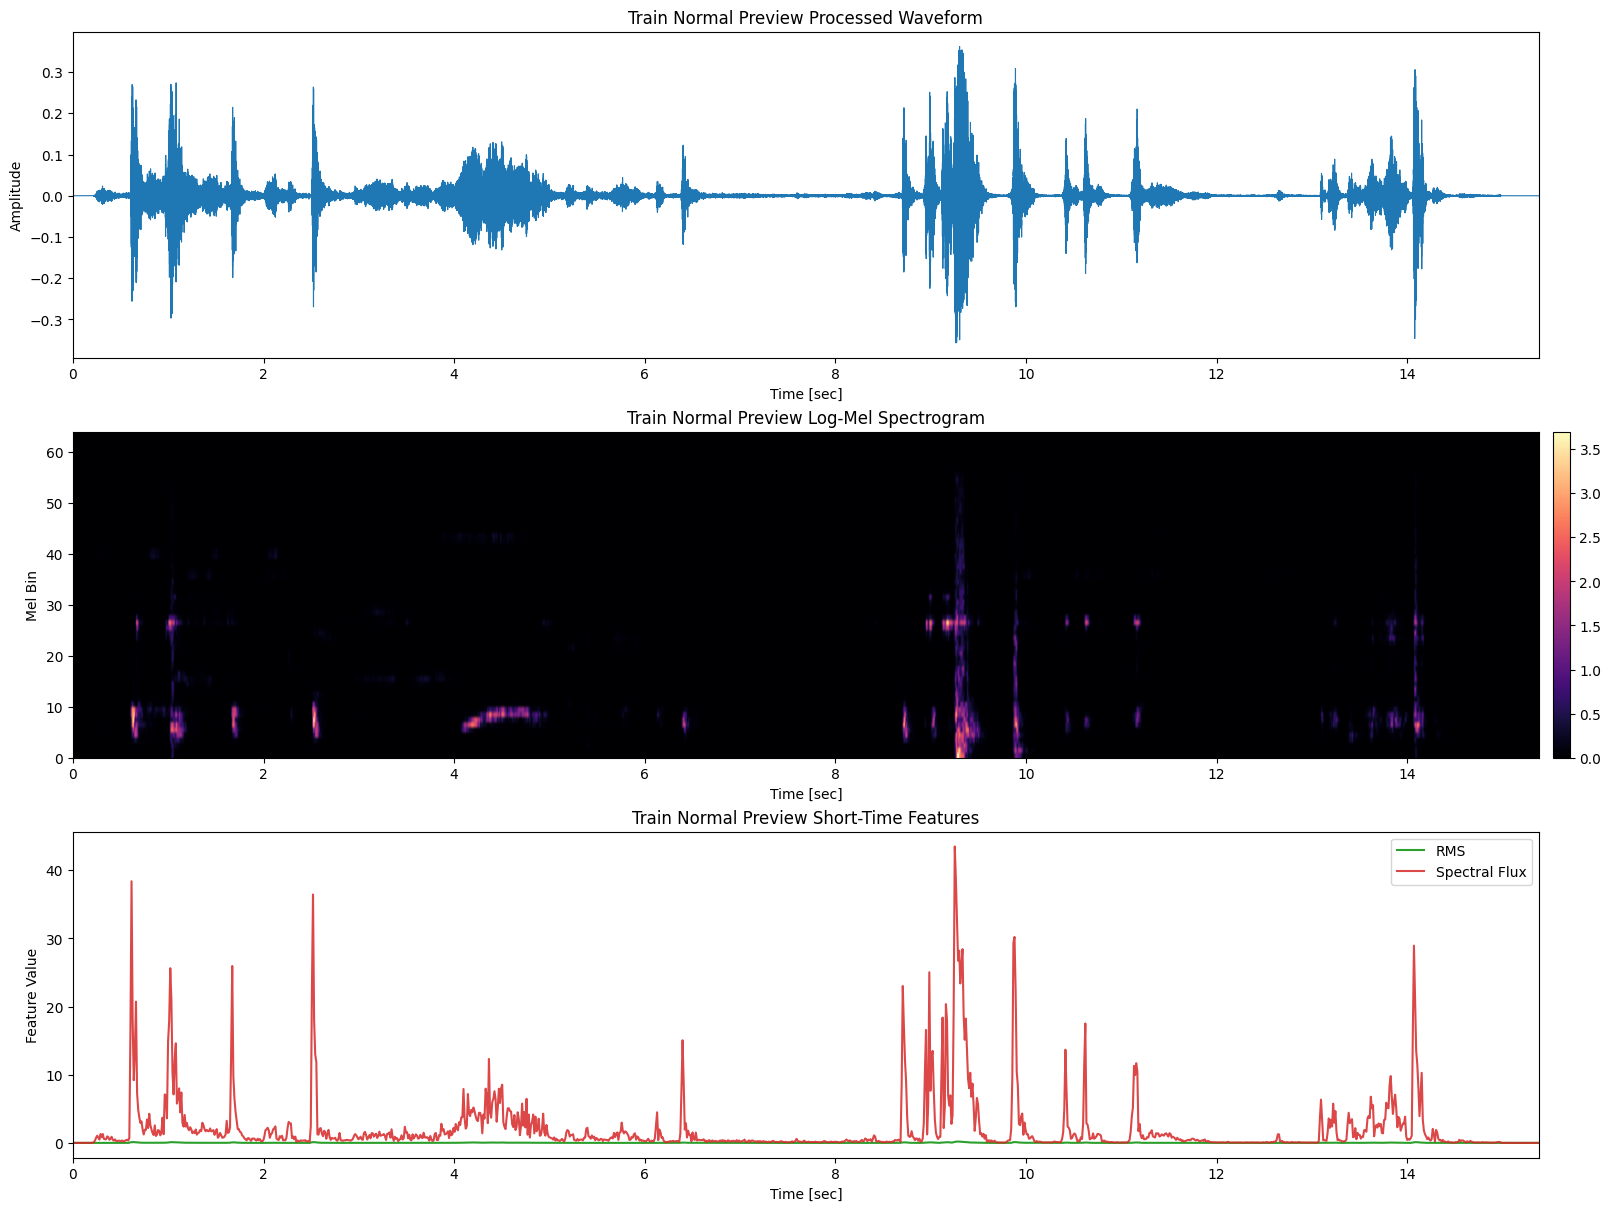

eval preview video: 001_後進時にトラックに衝突.mp4
eval preview label: anomary
eval preview wav path: ../outputs/audio_cache/eval/anomary/001_後進時にトラックに衝突.wav
eval preview clip stats: {'peak_abs': 1.005051612854004, 'rms': 0.12935864925384521, 'clipping_ratio': 0.0}
eval preview window count: 60


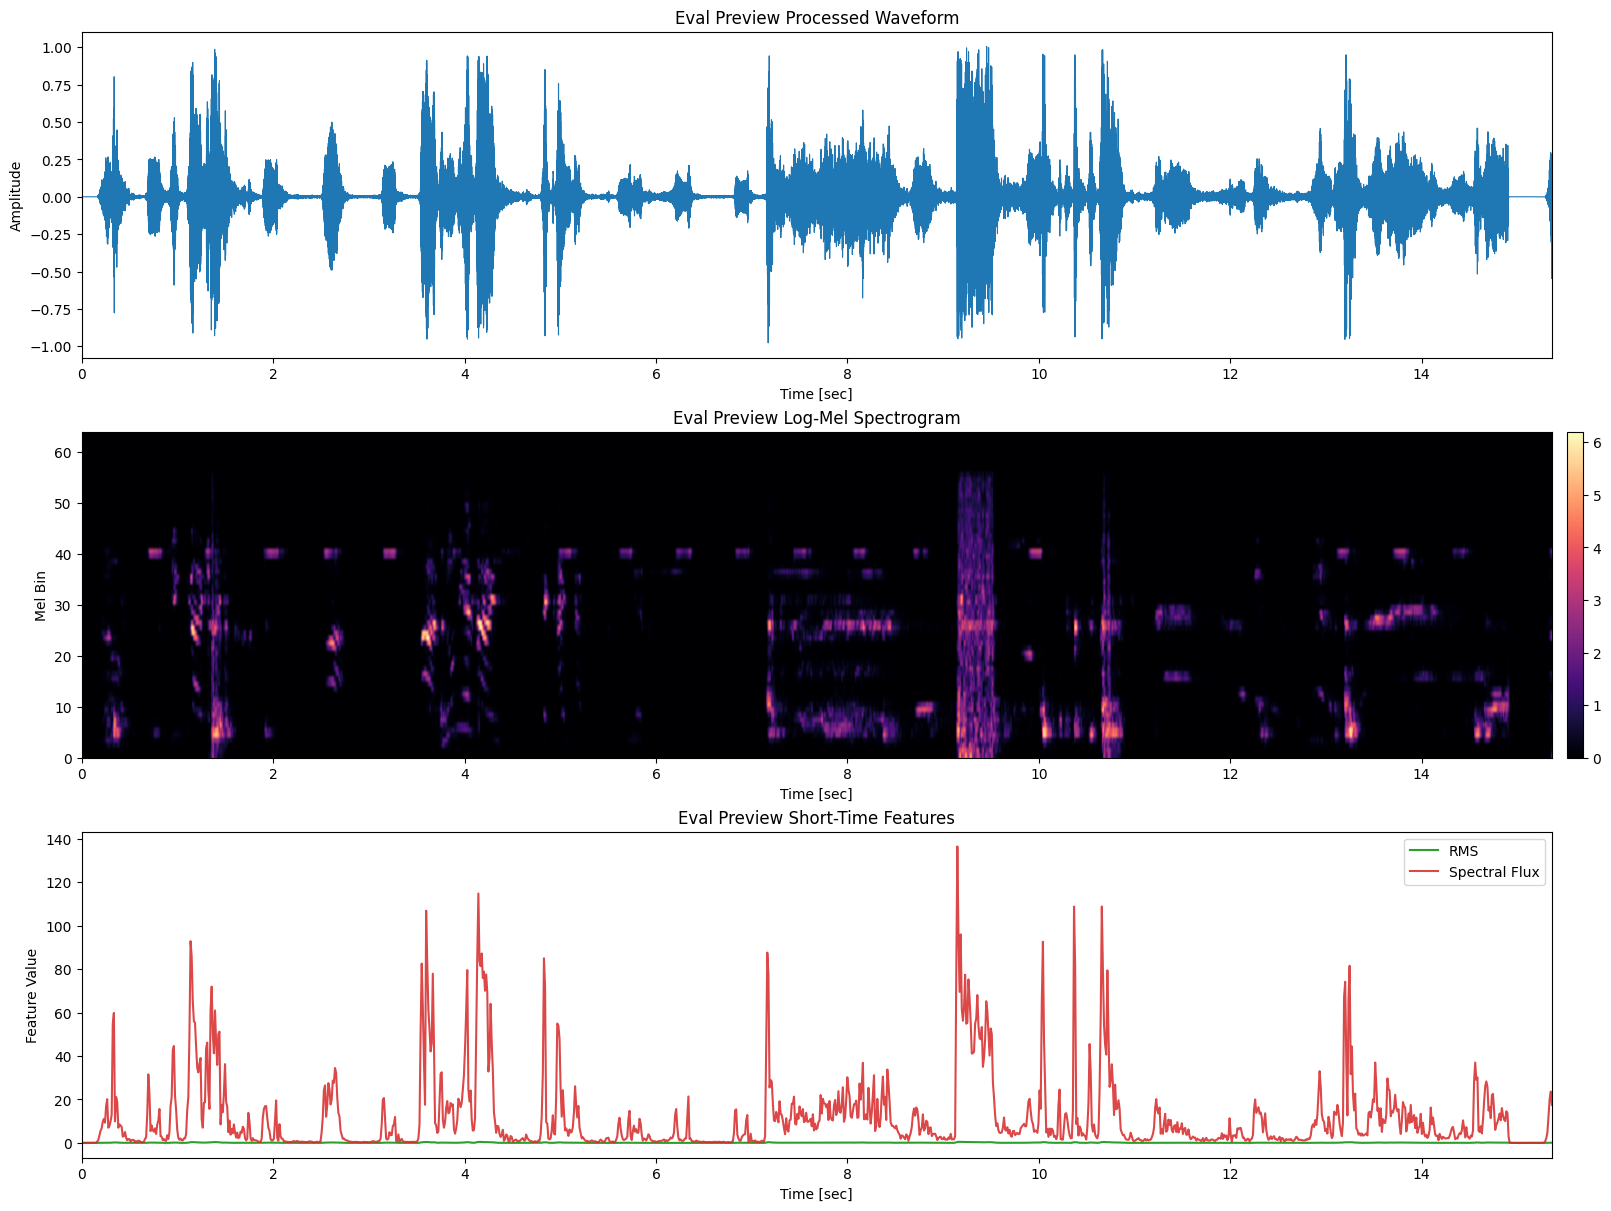

In [58]:
train_preview_analysis = None
eval_preview_analysis = None

train_preview_path = split_info["train_normal_paths"][0] if split_info["train_normal_paths"] else None
eval_preview_path = (
    split_info["eval_anomary_paths"][0]
    if split_info["eval_anomary_paths"]
    else (split_info["eval_normal_paths"][0] if split_info["eval_normal_paths"] else None)
)

if train_preview_path is None:
    print("Skip train audio preview because no training clips are available.")
else:
    train_preview_analysis = analyze_video_audio(train_preview_path, split_name="train", true_label="normal")
    print("train preview video:", train_preview_path.name)
    print("train preview wav path:", train_preview_analysis["wav_path"])
    print("train preview clip stats:", train_preview_analysis["clip_stats"])
    print("train preview window count:", len(train_preview_analysis["window_rows"]))
    show_figure(build_audio_preview_figure(train_preview_analysis, title_prefix="Train Normal Preview"))

if eval_preview_path is None:
    print("Skip eval audio preview because no evaluation clips are available.")
else:
    eval_preview_label = "anomary" if eval_preview_path in split_info["eval_anomary_paths"] else "normal"
    eval_preview_analysis = analyze_video_audio(eval_preview_path, split_name="eval", true_label=eval_preview_label)
    print("eval preview video:", eval_preview_path.name)
    print("eval preview label:", eval_preview_label)
    print("eval preview wav path:", eval_preview_analysis["wav_path"])
    print("eval preview clip stats:", eval_preview_analysis["clip_stats"])
    print("eval preview window count:", len(eval_preview_analysis["window_rows"]))
    show_figure(build_audio_preview_figure(eval_preview_analysis, title_prefix="Eval Preview"))


## 5. 平常音の学習と評価


train audio processed: 1003.mp4
train audio processed: 1004.mp4
train audio processed: 1005.mp4
train audio processed: 1006.mp4
train audio processed: 1007.mp4
train audio processed: 1008.mp4
train audio processed: 1009.mp4
train audio processed: 1011.mp4
train audio processed: 1012.mp4
train audio processed: 1013.mp4
train audio processed: 1017.mp4
train audio processed: 1018.mp4
train audio processed: 1019.mp4
train audio processed: 1020.mp4
train audio processed: 1021.mp4
train audio processed: 1022.mp4
train audio processed: 1023.mp4
train audio processed: 1024.mp4
train audio processed: 1025.mp4
train audio processed: 1026.mp4
train audio processed: 1027.mp4
train audio processed: 1028.mp4
train audio processed: 1029.mp4
train audio processed: 1030.mp4
train audio processed: 1031.mp4
train audio processed: 1032.mp4
train audio processed: 1033.mp4
train audio processed: 1034.mp4
train audio processed: 1035.mp4
train audio processed: 1036.mp4
train audio processed: 1037.mp4
train au

,video_name,split_name,true_label,predicted_label,clip_duration_sec,window_count,top_window_score,clip_anomaly_score,normal_score_threshold,is_correct
0,1001.mp4,eval,normal,anomary,15.488027,60,0.739014,0.734619,0.609393,False
1,1002.mp4,eval,normal,anomary,15.594694,61,0.713123,0.706410,0.609393,False
2,1046.mp4,eval,normal,anomary,15.594694,61,0.689791,0.664858,0.609393,False
3,001_後進時にトラックに衝突.mp4,eval,anomary,anomary,15.360000,60,0.657690,0.645960,0.609393,True
4,041_前進時、隣接荷物に衝突＆頭部殴打.mp4,eval,anomary,anomary,15.829342,62,0.669260,0.628029,0.609393,True
5,030_旋回時、安全ポール衝突＆後方から作業者.mp4,eval,anomary,anomary,15.829342,62,0.664624,0.625976,0.609393,True
6,018_後進時、柱に接触.mp4,eval,anomary,anomary,15.658685,61,0.646289,0.623168,0.609393,True
7,003_パレット落下.mp4,eval,anomary,anomary,15.850703,62,0.637679,0.618312,0.609393,True
8,014_旋回時、柱に衝突.mp4,eval,anomary,anomary,15.658685,61,0.640135,0.616401,0.609393,True
9,029_旋回時、安全ポールに衝突.mp4,eval,anomary,normal,15.765351,62,0.670539,0.608634,0.609393,False


top peak-volume clips:


,video_name,split_name,true_label,clip_peak_abs,clip_rms,clip_duration_sec
0,1001.mp4,eval,normal,1.078746,0.201606,15.488027
1,1006.mp4,train,normal,1.063241,0.089220,15.445351
2,1007.mp4,train,normal,1.057658,0.103548,15.850703
3,1057.mp4,train,normal,1.021704,0.063771,15.722676
4,001_後進時にトラックに衝突.mp4,eval,anomary,1.005052,0.129359,15.360000
5,1008.mp4,train,normal,0.995630,0.096954,15.552018
6,1009.mp4,train,normal,0.979692,0.086755,15.786667
7,1002.mp4,eval,normal,0.979420,0.143289,15.594694
8,1012.mp4,train,normal,0.949848,0.130939,15.594694
9,1065.mp4,train,normal,0.930210,0.073777,15.722676


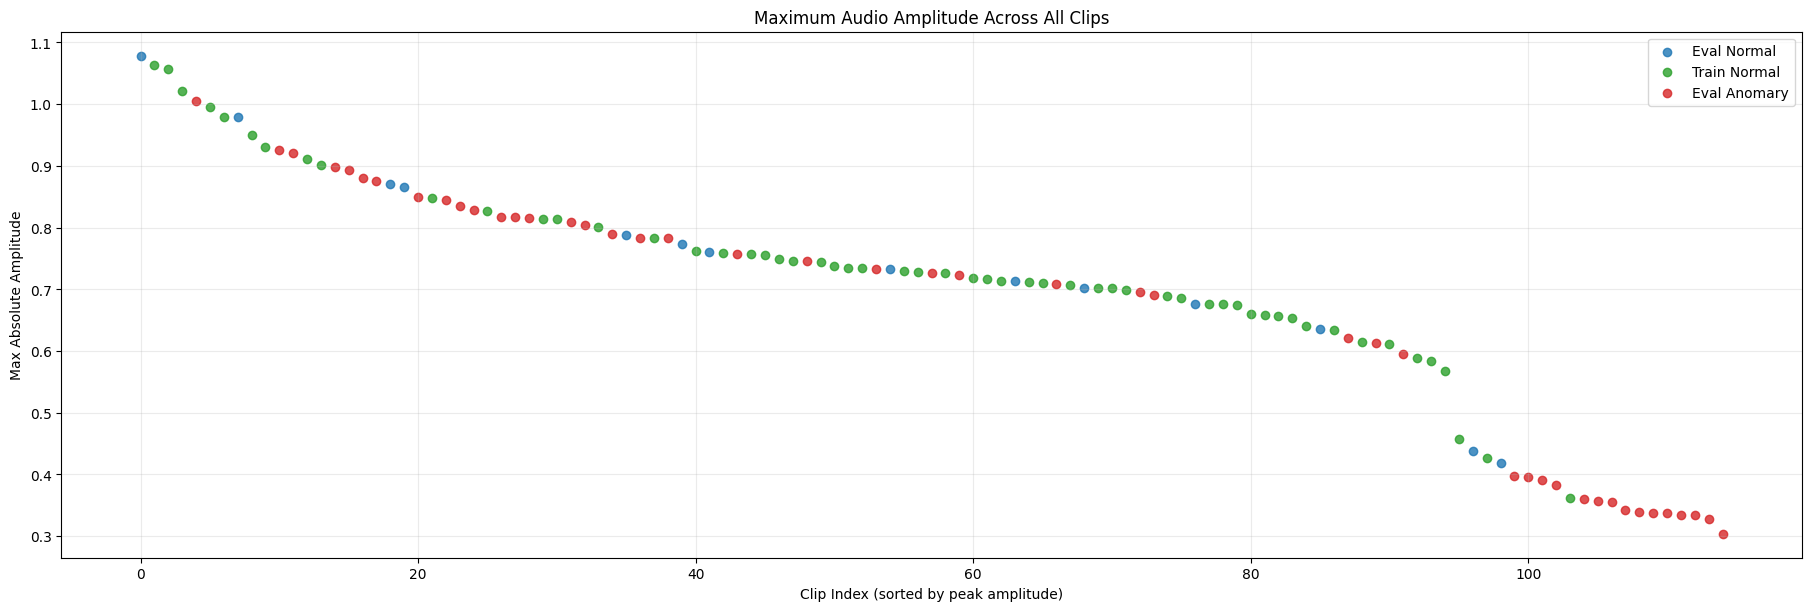

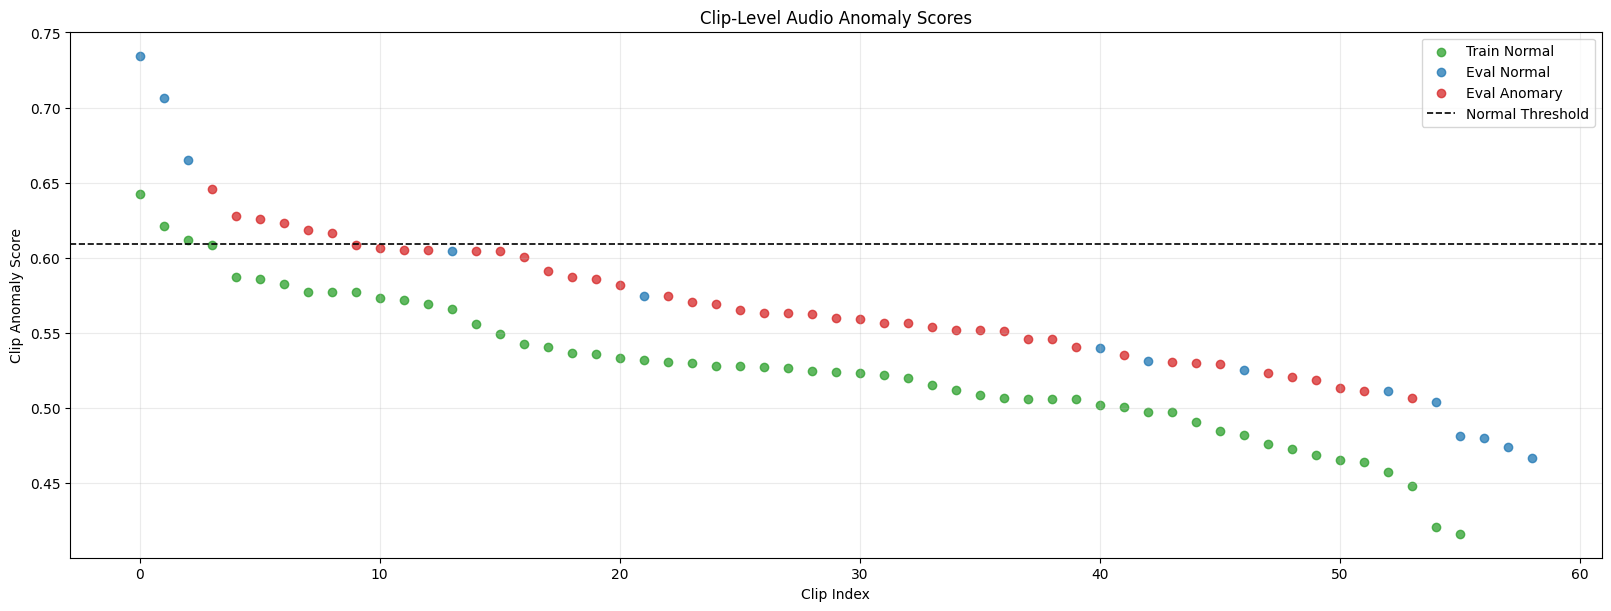

In [59]:
train_audio_analyses = []
eval_audio_analyses = []
audio_normal_model = None
train_clip_scores_df = pd.DataFrame()
eval_clip_scores_df = pd.DataFrame()
evaluation_results_df = pd.DataFrame()
peak_volume_df = pd.DataFrame()
normal_score_threshold = np.nan

for train_video_path in split_info["train_normal_paths"]:
    train_audio_analysis = analyze_video_audio(train_video_path, split_name="train", true_label="normal")
    train_audio_analyses.append(train_audio_analysis)
    print("train audio processed:", train_video_path.name)

train_window_rows = collect_audio_window_rows(train_audio_analyses)
print("train audio window count:", len(train_window_rows))

if not train_window_rows:
    print("Skip model training because training windows are empty.")
else:
    audio_normal_model = fit_audio_normal_model(train_window_rows)
    print("trained feature dimension:", audio_normal_model["feature_dimension"])
    print("trained pca components:", audio_normal_model["pca_components"])
    print("pca explained variance ratio:", audio_normal_model["explained_variance_ratio"])
    print(
        "train window anomaly score stats:",
        {
            "min": float(np.min(audio_normal_model["train_scores"])),
            "median": float(np.median(audio_normal_model["train_scores"])),
            "max": float(np.max(audio_normal_model["train_scores"])),
        },
    )

    train_scored_rows = score_audio_windows(audio_normal_model, train_window_rows)
    train_clip_scores_df = summarize_clip_scores(train_scored_rows, top_k=AUDIO_CLIP_SCORE_TOP_K)
    normal_score_threshold = float(
        np.percentile(train_clip_scores_df["clip_anomaly_score"], NORMAL_SCORE_THRESHOLD_PERCENTILE)
    )
    print("normal score threshold:", normal_score_threshold)

    eval_video_specs = (
        [(path, "normal") for path in split_info["eval_normal_paths"]]
        + [(path, "anomary") for path in split_info["eval_anomary_paths"]]
    )
    for eval_video_path, eval_true_label in eval_video_specs:
        eval_audio_analysis = analyze_video_audio(eval_video_path, split_name="eval", true_label=eval_true_label)
        eval_audio_analyses.append(eval_audio_analysis)
        print("eval audio processed:", eval_video_path.name, eval_true_label)

    eval_window_rows = collect_audio_window_rows(eval_audio_analyses)
    print("eval audio window count:", len(eval_window_rows))

    eval_scored_rows = score_audio_windows(audio_normal_model, eval_window_rows)
    eval_clip_scores_df = summarize_clip_scores(eval_scored_rows, top_k=AUDIO_CLIP_SCORE_TOP_K)

    if not eval_clip_scores_df.empty:
        evaluation_results_df = eval_clip_scores_df.copy()
        evaluation_results_df["normal_score_threshold"] = float(normal_score_threshold)
        evaluation_results_df["predicted_label"] = np.where(
            evaluation_results_df["clip_anomaly_score"] > float(normal_score_threshold),
            "anomary",
            "normal",
        )
        evaluation_results_df["is_correct"] = (
            evaluation_results_df["predicted_label"] == evaluation_results_df["true_label"]
        )
        evaluation_results_df = evaluation_results_df.sort_values(
            ["clip_anomaly_score", "video_name"],
            ascending=[False, True],
        ).reset_index(drop=True)

        print("evaluation result counts:")
        print(evaluation_results_df.groupby(["true_label", "predicted_label"]).size())
        evaluation_display_columns = [
            "video_name",
            "split_name",
            "true_label",
            "predicted_label",
            "clip_duration_sec",
            "window_count",
            "top_window_score",
            "clip_anomaly_score",
            "normal_score_threshold",
            "is_correct",
        ]
        display(evaluation_results_df[evaluation_display_columns])
        peak_volume_df = summarize_peak_volume(train_audio_analyses + eval_audio_analyses)
        peak_volume_display_columns = [
            "video_name",
            "split_name",
            "true_label",
            "clip_peak_abs",
            "clip_rms",
            "clip_duration_sec",
        ]
        print("top peak-volume clips:")
        display(peak_volume_df[peak_volume_display_columns].head(20))
        show_figure(build_peak_volume_figure(peak_volume_df))
        show_figure(build_clip_score_figure(train_clip_scores_df, eval_clip_scores_df, normal_score_threshold))


In [60]:
if evaluation_results_df.empty:
    print("Skip saving evaluation results because no evaluation rows are available.")
else:
    ensure_output_directory(EVALUATION_RESULTS_PATH)
    evaluation_results_df.to_csv(EVALUATION_RESULTS_PATH, index=False)
    print("evaluation results saved to:", EVALUATION_RESULTS_PATH)


evaluation results saved to: ../outputs/audio_evaluation_results.csv
